In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from leela_interp.core.effect_study import *
from leela_interp.core.alternative_moves import *
from leela_interp.core.double_branch import *
from leela_interp.core.fifth_move_study import *
from leela_interp.core.checkmate_study import *
from leela_interp.core.general_study import *
from leela_interp.core.ablation_study import AblationStudy
from leela_interp.core.probing_study import ProbingStudy
from leela_interp.core.double_attention_study import *
import subprocess
# Disable FutureWarning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("cpu")
model = Lc0sight("lc0.onnx", device=device)

Using device: cpu


# 9th move analysis

## Residual stream

In [4]:
# general_study = GeneralStudy(puzzlename="pv9", load_all=True)
# general_study.find_result_sets(include_starting=False, n_examples=10)
# general_study.export_puzzle_set_info()

In [5]:
study = CheckmateStudy(puzzlename="pv9", load_all=False)

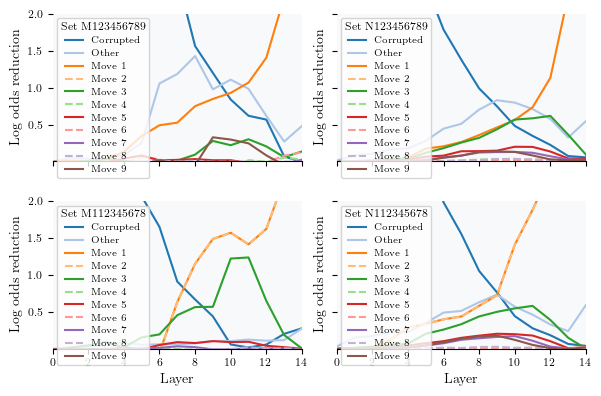

<Figure size 640x480 with 0 Axes>

In [30]:
possibilities = study.get_possibility_list('n', lengths=[9])
study.plot_residual_effects_grid('n', good_possibilities[:2], n_cols=1, filename="paper_residual_effects_9_checkmate_good", y_max=2, plot_ci=False)

## Attention heads

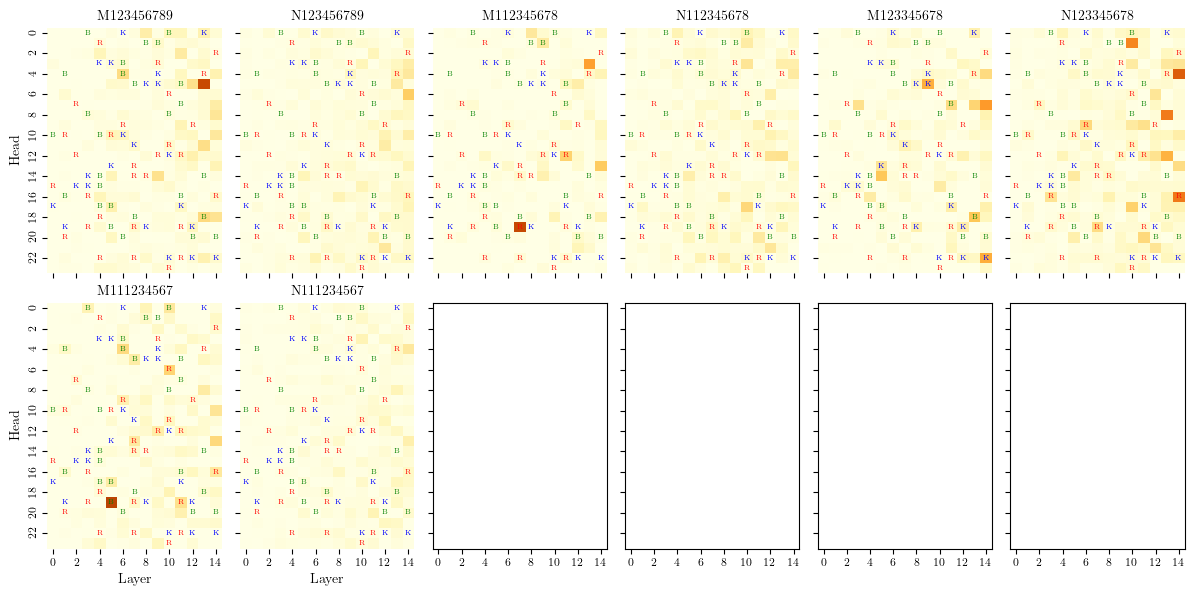

<Figure size 640x480 with 0 Axes>

In [ ]:
possibilities = study.get_possibility_list('n', lengths=[9])
study.plot_attention_grid('n', possibilities, n_cols=3, filename="paper_attention_heads_9_checkmate", vmax=0.73)

In [8]:
[(possibility, len(study.puzzle_sets['n'][possibility])) for possibility in possibilities]

[('122234566', 13),
 ('111234567', 146),
 ('122234567', 40),
 ('112345667', 22),
 ('123451167', 19),
 ('123456678', 27),
 ('123456667', 36),
 ('123456789', 387),
 ('123445678', 30),
 ('123456758', 11),
 ('123342567', 39),
 ('122223455', 12),
 ('112314567', 13),
 ('112345267', 13),
 ('123145678', 10),
 ('112234567', 20),
 ('123456677', 16),
 ('123456788', 91),
 ('122345677', 13),
 ('112223456', 16),
 ('112345566', 15),
 ('112333456', 22),
 ('112345627', 14),
 ('112341567', 27),
 ('112345675', 16),
 ('123334566', 15),
 ('111234566', 31),
 ('112314566', 14),
 ('123455567', 43),
 ('122345678', 35),
 ('123456778', 25),
 ('112345567', 32),
 ('123345566', 21),
 ('123456718', 10),
 ('112345677', 109),
 ('123334567', 37),
 ('112345556', 25),
 ('123444566', 10),
 ('111234556', 17),
 ('123456278', 12),
 ('123455678', 26),
 ('123456378', 12),
 ('123345678', 158),
 ('122134567', 24),
 ('123114567', 10),
 ('112334567', 25),
 ('112345617', 23),
 ('123456786', 16),
 ('123445677', 16),
 ('112345167', 3

In [9]:
from operator import itemgetter   # optional, but tidy

counts = [(p, len(study.puzzle_sets['n'][p]))          # build the tuples
          for p in possibilities]

# sort by the “count” (index 1) largest → smallest
counts_sorted = sorted(counts, key=itemgetter(1), reverse=True)

# view the result
for puzzle, total in counts_sorted:
    print(puzzle, total)

123456789 387
112345678 381
123345678 158
111234567 146
112345677 109
123456788 91
123455567 43
122234567 40
123342567 39
123334567 37
123456667 36
122345678 35
123444567 33
112345567 32
111234566 31
123445678 30
112345167 30
123456678 27
112341567 27
111123456 27
123455678 26
123456778 25
112345556 25
112334567 25
122134567 24
123345677 24
112345617 23
112345667 22
112333456 22
123345566 21
112234567 20
123451167 19
111234556 17
123456677 16
112223456 16
112345675 16
123456786 16
123445677 16
112345566 15
123334566 15
123456782 15
112345627 14
112314566 14
111233456 14
122234566 13
112314567 13
112345267 13
122345677 13
112344567 13
112344456 13
122223455 12
123456278 12
123456378 12
112345637 12
123456738 12
123456758 11
123145678 10
123456718 10
123444566 10
123114567 10


In [19]:
# starting from counts_sorted (already sorted desc on the count)
unique_last_sorted = [
    (puzzle, total)
    for puzzle, total in counts_sorted
    if puzzle.count(puzzle[-1]) == 1      # last digit appears exactly once
]

# display
for puzzle, total in unique_last_sorted:
    print(puzzle, total)

123456789 387
112345678 381
123345678 158
111234567 146
123455567 43
122234567 40
123342567 39
123334567 37
123456667 36
122345678 35
123444567 33
112345567 32
123445678 30
112345167 30
123456678 27
112341567 27
111123456 27
123455678 26
123456778 25
112345556 25
112334567 25
122134567 24
112345617 23
112345667 22
112333456 22
112234567 20
123451167 19
111234556 17
112223456 16
112345627 14
111233456 14
112314567 13
112345267 13
112344567 13
112344456 13
123456278 12
123456378 12
112345637 12
123456738 12
123456758 11
123145678 10
123456718 10
123114567 10


In [22]:
good_possibilities = [possibility for possibility, count in unique_last_sorted][:4]

In [23]:
good_possibilities

['123456789', '112345678', '123345678', '111234567']

In [24]:
# import subprocess

# ablation_configs = [
#     ('L12H12', "1112345"),
#     ('L12H12', "1111234"),
# ]

# for config in ablation_configs:
#     layer_head, puzzle = config
#     layer = layer_head[1:3]  # Extract layer number
#     head = layer_head[4:]    # Extract head number
    
#     command = f"python3 scripts/run_single_head.py --filename interesting_puzzles_pv7_n_{puzzle} --layer {layer} --head {head} --device cuda --main"
    
#     print(f"Running command: {command}")
#     subprocess.run(command, shell=True)
#     print("Command completed.\n")

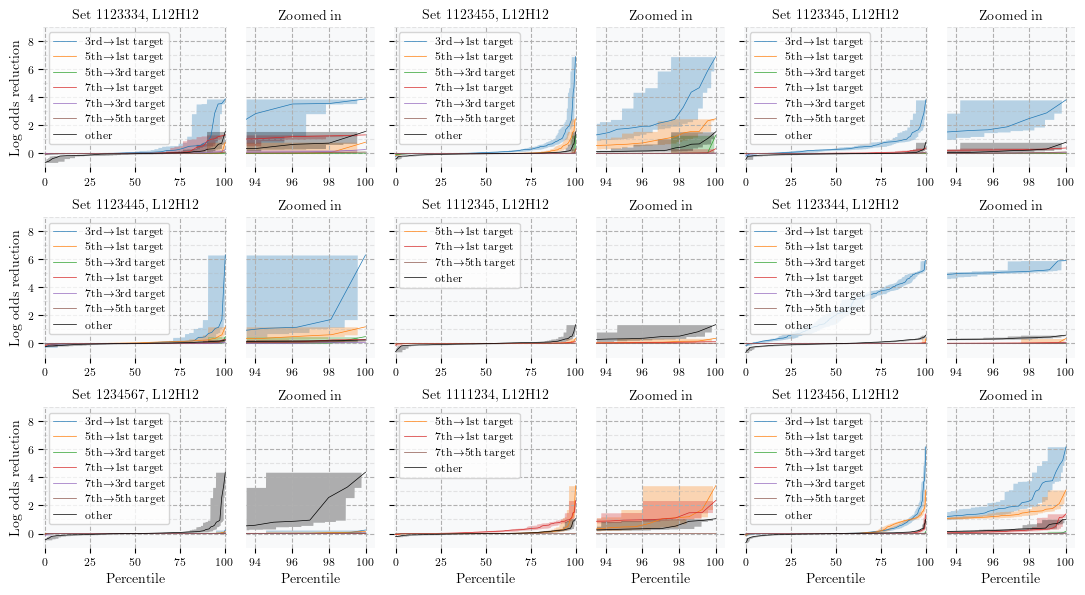

In [15]:
ablation_study = AblationStudy(folder_name="")
ablation_configs = [
    ('L12H12', "1123334"),
    ('L12H12', "1123455"),
    ('L12H12', "1123345"),
    ('L12H12', "1123445"),
    ('L12H12', "1112345"),
    ('L12H12', "1123344"),
    ('L12H12', "1234567"),
    ('L12H12', "1111234"),
    ('L12H12', "1123456")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_7_L12H12", tag='pv7_n')

## Probing

In [24]:
for possibility in good_possibilities:

    command = f"python3 scripts/probing.py --filename interesting_puzzles_pv9_n_{possibility} --main --random_model --n_seeds 5 --max_goal_square 9"
    
    print(f"Running command: {command}")
    subprocess.run(command, shell=True)
    print("Command completed.\n")

Running command: python3 scripts/probing.py --filename interesting_puzzles_pv9_n_123456789 --main --random_model --n_seeds 5 --max_goal_square 9
common_str: pv9_n
Using 387 puzzles total, 270 for training.
Using device: cuda


100%|██████████| 15/15 [00:00<00:00, 28.23it/s]


Using device: cuda


100%|██████████| 15/15 [00:00<00:00, 28.87it/s]


Command completed.

Running command: python3 scripts/probing.py --filename interesting_puzzles_pv9_n_112345678 --main --random_model --n_seeds 5 --max_goal_square 9
common_str: pv9_n
Using 381 puzzles total, 266 for training.
Using device: cuda


...

Command completed.

Running command: python3 scripts/probing.py --filename interesting_puzzles_pv9_n_111234567 --main --random_model --n_seeds 5 --max_goal_square 9
common_str: pv9_n
Using 146 puzzles total, 102 for training.
Using device: cuda


100%|██████████| 15/15 [00:00<00:00, 76.33it/s]


Using device: cuda


100%|██████████| 15/15 [00:00<00:00, 77.04it/s]


Command completed.



387


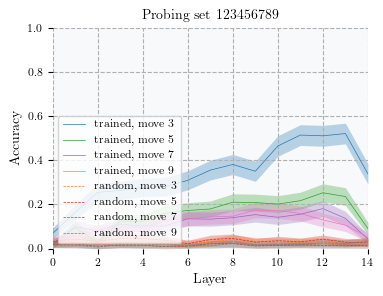

381


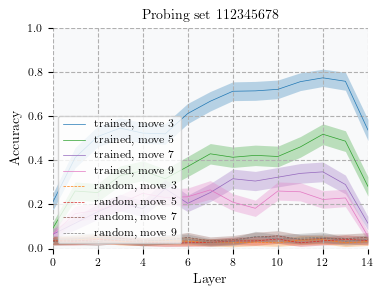

158


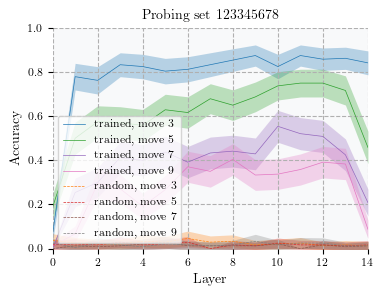

146


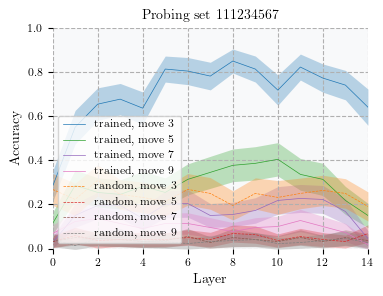

In [25]:
cases = good_possibilities

for case in cases:
    probing_study = ProbingStudy(case_number=case, tag_name='pv9_n')
    print(probing_study.n_examples)
    probing_study.plot_probe_results(filename="paper_probe_results_" + case)

# Double branches

In [21]:
from leela_interp.core.double_branch import DoubleBranchStudy

In [22]:
study = DoubleBranchStudy(puzzlename="nomate2", load_all=True)

123425 4 4


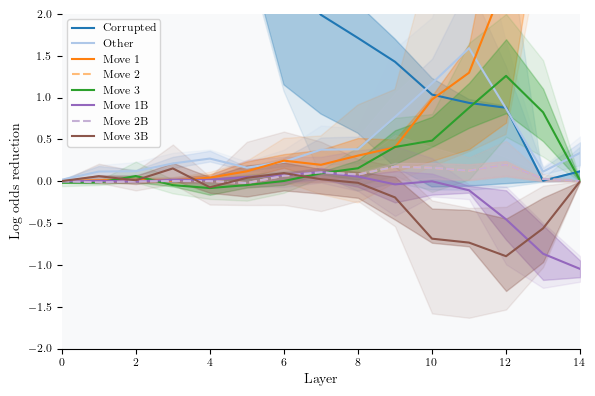

In [23]:
study.plot_residual_effects('b', '123425', filename="paper_residual_effects_123425")